In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import datetime
%matplotlib inline

In [3]:
orig_df = pd.read_csv('airline_passengers.csv')
orig_df.head()

,Month,Thousands of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
orig_df.dtypes

Month                      object
Thousands of Passengers     int64
dtype: object

In [5]:
df = orig_df.copy()

### Handling Missing Times and Missing Values

In [6]:
# find missing value percent for each variable
null_percent = df.isnull().sum()/len(df)*100
null_percent

Month                      0.0
Thousands of Passengers    0.0
dtype: float64

In [7]:
# Frequenct String: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
# Frequency examples: 'YE' = year, 'QE' = quarter, 'W' = week, 'D' = day, 'h' = hour, 'min' = minute, 's' = second
# >>> forward filling
# df[value_var] = df[value_var].asfreq(freq='YE', method='ffill')     
# >>> backward filling
# df[value_var] = df[value_var].asfreq(freq='YE', method='bfill')    
# >>> resample (average)
# df[value_var] = df[value_var].resample('YE').mean()  

### Set time index

#### String Time Format Code List: https://strftime.org/

In [8]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m') # Match format according to the data pattern
df.head()

,Month,Thousands of Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [9]:
df.dtypes

Month                      datetime64[ns]
Thousands of Passengers             int64
dtype: object

In [10]:
# Set column with datetime as index of dataframe
df = df.set_index('Month')
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [11]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

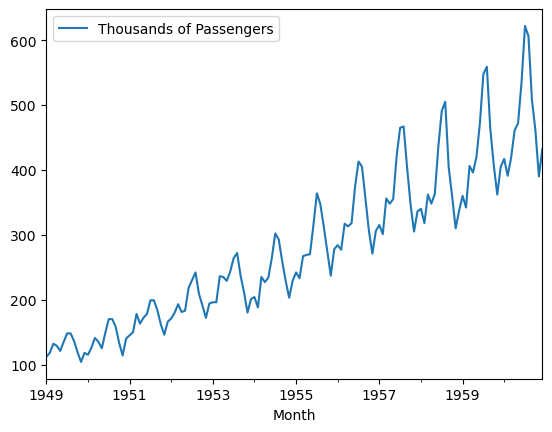

In [12]:
# Visualization timeseries
df.plot()
plt.show()

### Data Preprocessing

In [13]:
### Detecting and removing outliers using SD

In [14]:
from scipy.stats import zscore
z_scores = zscore(df)
abs_z_scores = np.abs(z_scores)
abs_z_scores[1:10]

array([[1.35759023],
       [1.24048348],
       [1.26557778],
       [1.33249593],
       [1.21538918],
       [1.10664719],
       [1.10664719],
       [1.20702441],
       [1.34922546]])

In [15]:
zscore_threshold = 3 #any data above mean +/- (this_threshold)*sd is considered outliers
outliers = (abs_z_scores > zscore_threshold)  # Z-score threshold
df_outlier_removed = df[~outliers]   
df_outlier_removed[1:10]

,Thousands of Passengers
Month,
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136
1949-10-01,119


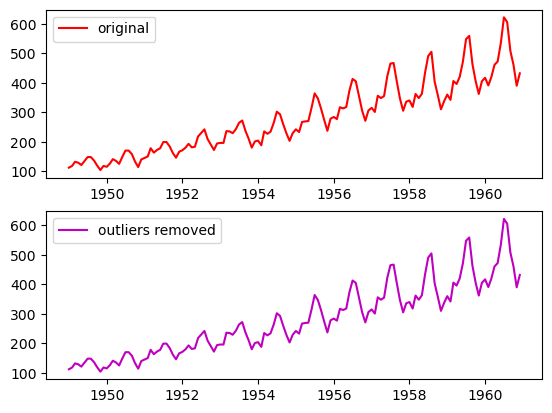

In [16]:
# Plot to compare original and outlier_removed
fig, ax = plt.subplots(2,1)
temp_line, = ax[0].plot(df.index, df, label='original', color='r')
temp_line, = ax[1].plot(df_outlier_removed.index, df_outlier_removed, label='outliers removed', color='m')
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')
plt.show()

(144, 1)
(129, 1)


<Figure size 640x480 with 0 Axes>

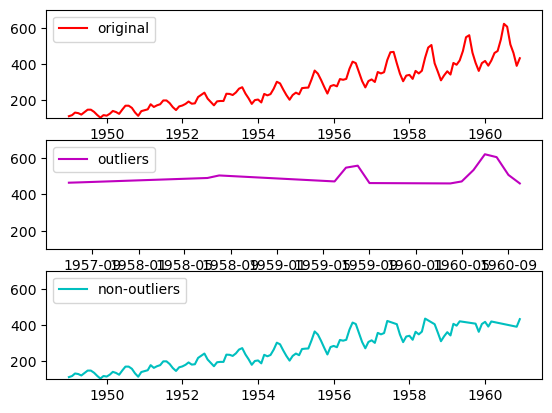

In [17]:
# See effect of outlier removal by changing zscore_threshold value
plt.clf()
zscore_threshold = 1.5 #any data above mean +/- (this_threshold)*sd is considered outliers
outliers = (abs_z_scores > zscore_threshold)  # Z-score threshold
df_outliers = df[outliers]
df_nonoutliers = df[~outliers]

fig, ax = plt.subplots(3,1)
temp_line, = ax[0].plot(df.index, df, label='original', color='r')
temp_line, = ax[1].plot(df_outliers.index, df_outliers, label='outliers', color='m')
temp_line, = ax[2].plot(df_nonoutliers.index, df_nonoutliers, label='non-outliers', color='c')
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')
ax[2].legend(loc='upper left')
ax[0].set_ylim([100, 700])
ax[1].set_ylim([100, 700])
ax[2].set_ylim([100, 700])

print(df.shape)
print(df_nonoutliers.shape)
plt.show()

In [18]:
### Detecting and removing outliers using percentile

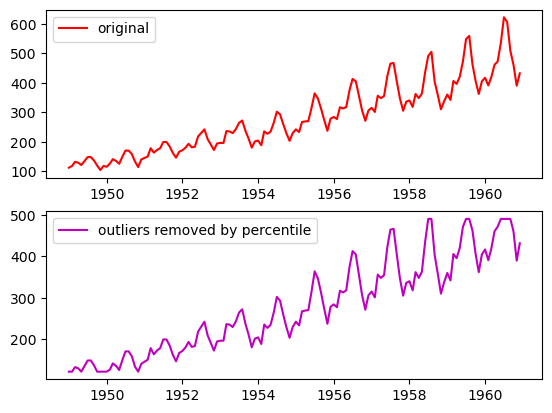

In [19]:
from scipy.stats.mstats import winsorize # Technical name for using remove outlier with percentile

# Limits outliers to the 5th and 95th percentiles
df_outlier_removed_p = winsorize(df['Thousands of Passengers'], limits=[0.05, 0.05])

# Plot to compare original and outlier_removed
fig, ax = plt.subplots(2,1)
temp_line, = ax[0].plot(df.index, df, label='original', color='r')
temp_line, = ax[1].plot(df.index, df_outlier_removed_p, label='outliers removed by percentile', color='m')
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')
plt.show()

### Process Timeseries

### Frequency Setting

#### Frequenct String: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases

#### Frequency examples: 'YE' = year, 'QE' = quarter, 'W' = week, 'D' = day, 'h' = hour, 'min' = minute, 's' = second

In [20]:
# To check whether the frequency of timeseries is correct or not
# Frequency strings can be looked at: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
df.index.inferred_freq

'MS'

In [21]:
# Sampling using resample and mean
sampling_set = df['Thousands of Passengers'].resample('YE').mean()  # one sample = average over time 
sampling_set

Month
1949-12-31    126.666667
1950-12-31    139.666667
1951-12-31    170.166667
1952-12-31    197.000000
1953-12-31    225.000000
1954-12-31    238.916667
1955-12-31    284.000000
1956-12-31    328.250000
1957-12-31    368.416667
1958-12-31    381.000000
1959-12-31    428.333333
1960-12-31    476.166667
Freq: YE-DEC, Name: Thousands of Passengers, dtype: float64

In [22]:
df[1:40]['Thousands of Passengers']

Month
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
1950-08-01    170
1950-09-01    158
1950-10-01    133
1950-11-01    114
1950-12-01    140
1951-01-01    145
1951-02-01    150
1951-03-01    178
1951-04-01    163
1951-05-01    172
1951-06-01    178
1951-07-01    199
1951-08-01    199
1951-09-01    184
1951-10-01    162
1951-11-01    146
1951-12-01    166
1952-01-01    171
1952-02-01    180
1952-03-01    193
1952-04-01    181
Name: Thousands of Passengers, dtype: int64

In [23]:
# Sampling using asfreq (ffill = forward fill, bfill = backward fill)
ffill_freq_set = df['Thousands of Passengers'].asfreq(freq='YE', method='ffill')     # one sample = data selected at end of time
ffill_freq_set

Month
1949-12-31    118
1950-12-31    140
1951-12-31    166
1952-12-31    194
1953-12-31    201
1954-12-31    229
1955-12-31    278
1956-12-31    306
1957-12-31    336
1958-12-31    337
1959-12-31    405
Freq: YE-DEC, Name: Thousands of Passengers, dtype: int64

In [24]:
# Sampling using asfreq (ffill = forward fill, bfill = backward fill)
bfill_freq_set = df['Thousands of Passengers'].asfreq(freq='YE', method='bfill')     # one sample = data selected at beginning of time
bfill_freq_set

Month
1949-12-31    115
1950-12-31    145
1951-12-31    171
1952-12-31    196
1953-12-31    204
1954-12-31    242
1955-12-31    284
1956-12-31    315
1957-12-31    340
1958-12-31    360
1959-12-31    417
Freq: YE-DEC, Name: Thousands of Passengers, dtype: int64

<Figure size 640x480 with 0 Axes>

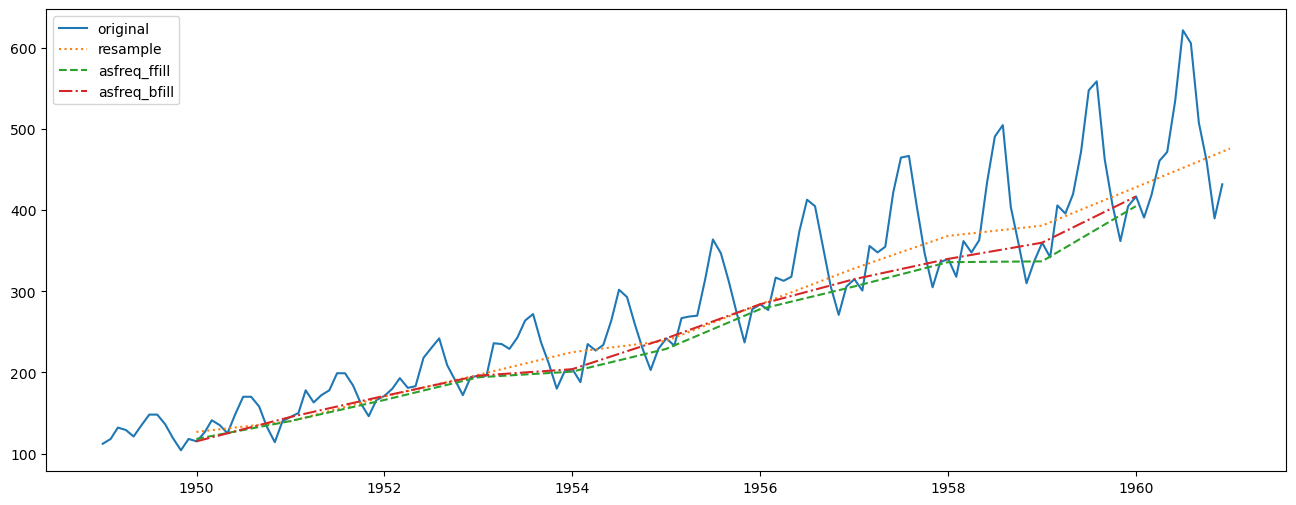

In [25]:
# Plot sample sets
plt.clf()
fig = plt.figure(figsize=(16,6)) 
plt.plot(df['Thousands of Passengers'].index, df['Thousands of Passengers'])              
plt.plot(sampling_set.index, sampling_set, ':')              
plt.plot(ffill_freq_set.index, ffill_freq_set, '--')              
plt.plot(bfill_freq_set.index, bfill_freq_set, '-.')              
plt.legend(['original','resample','asfreq_ffill','asfreq_bfill'], loc='upper left')
plt.show()

### Time shifting

In [26]:
# Before shifting
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [27]:
# Shifting 1 unit
shifted_period = 1
df_shifted = df.shift(periods=shifted_period)
df_shifted.head() 

,Thousands of Passengers
Month,
1949-01-01,NaN
1949-02-01,112.0
1949-03-01,118.0
1949-04-01,132.0
1949-05-01,129.0


<Figure size 640x480 with 0 Axes>

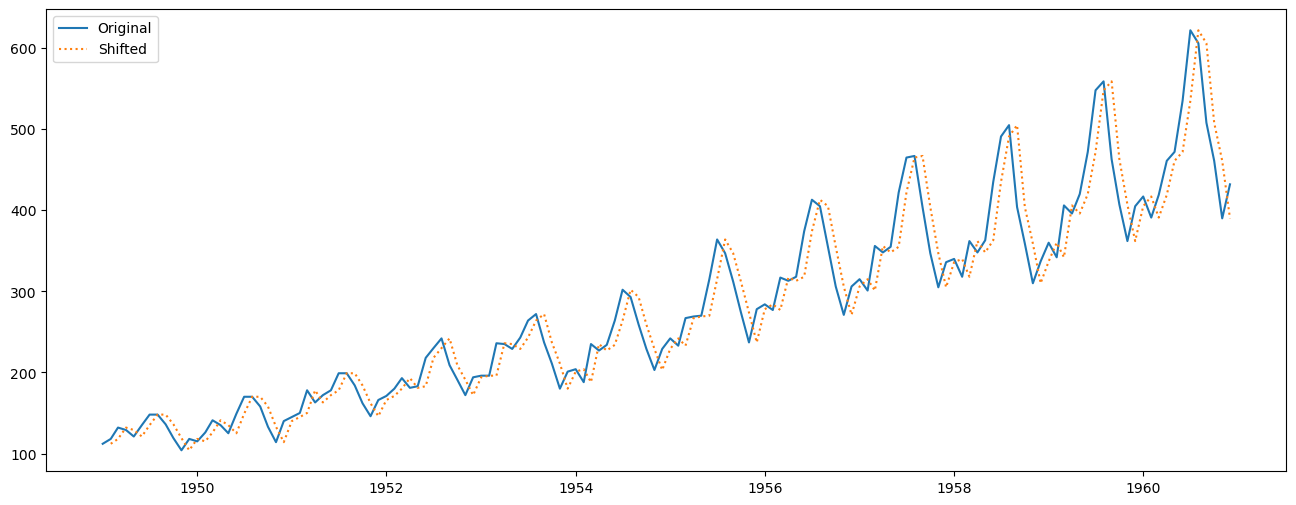

In [28]:
plt.clf()
fig = plt.figure(figsize=(16,6)) 
plt.plot(df['Thousands of Passengers'].index, df['Thousands of Passengers'])              
plt.plot(df_shifted.index, df_shifted['Thousands of Passengers'], ':')              
plt.legend(['Original','Shifted'],loc='upper left')
plt.show()

## Smoothing: Moving Average

In [29]:
# one-sided moving average, window size = 6
df['6-month-SMA'] = df['Thousands of Passengers'].rolling(window=6).mean()

In [30]:
# one-sided moving average, window size = 12
df['12-month-SMA'] = df['Thousands of Passengers'].rolling(window=12).mean()

In [31]:
# two-sided moving average, window size = 12
df['6-month-SMA-Center'] = df['Thousands of Passengers'].rolling(window=6,center=True).mean()

In [32]:
df.head(15)

,Thousands of Passengers,6-month-SMA,12-month-SMA,6-month-SMA-Center
Month,,,,
1949-01-01,112,NaN,NaN,NaN
1949-02-01,118,NaN,NaN,NaN
1949-03-01,132,NaN,NaN,NaN
1949-04-01,129,NaN,NaN,124.500000
1949-05-01,121,NaN,NaN,130.500000
1949-06-01,135,124.500000,NaN,135.500000
1949-07-01,148,130.500000,NaN,136.166667
1949-08-01,148,135.500000,NaN,134.500000
1949-09-01,136,136.166667,NaN,131.666667


In [33]:
df.tail(15)

,Thousands of Passengers,6-month-SMA,12-month-SMA,6-month-SMA-Center
Month,,,,
1959-10-01,407,478.166667,418.333333,457.333333
1959-11-01,362,468.500000,422.666667,435.500000
1959-12-01,405,457.333333,428.333333,407.500000
1960-01-01,417,435.500000,433.083333,400.166667
1960-02-01,391,407.500000,437.166667,409.166667
1960-03-01,419,400.166667,438.250000,427.500000
1960-04-01,461,409.166667,443.666667,449.166667
1960-05-01,472,427.500000,448.000000,483.333333
1960-06-01,535,449.166667,453.250000,519.166667


<Figure size 640x480 with 0 Axes>

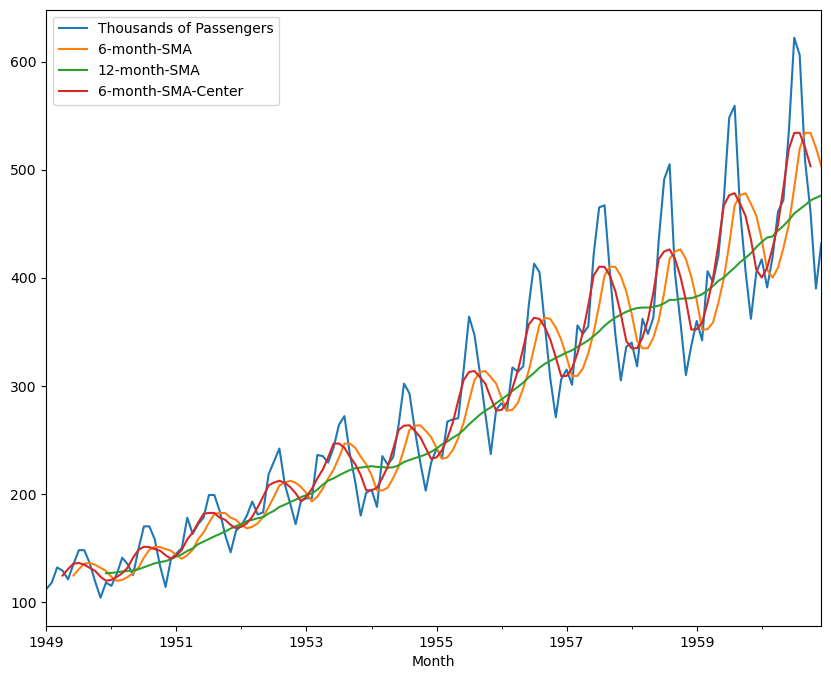

In [34]:
plt.clf()
df.plot(figsize=(10,8))
plt.show()

## Smoothing: Exponential Smoothing

In [35]:
df['EWMA-0.3'] = df['Thousands of Passengers'].ewm(alpha=0.3,adjust=False).mean()

In [36]:
df['EWMA-0.6'] = df['Thousands of Passengers'].ewm(alpha=0.6,adjust=False).mean()

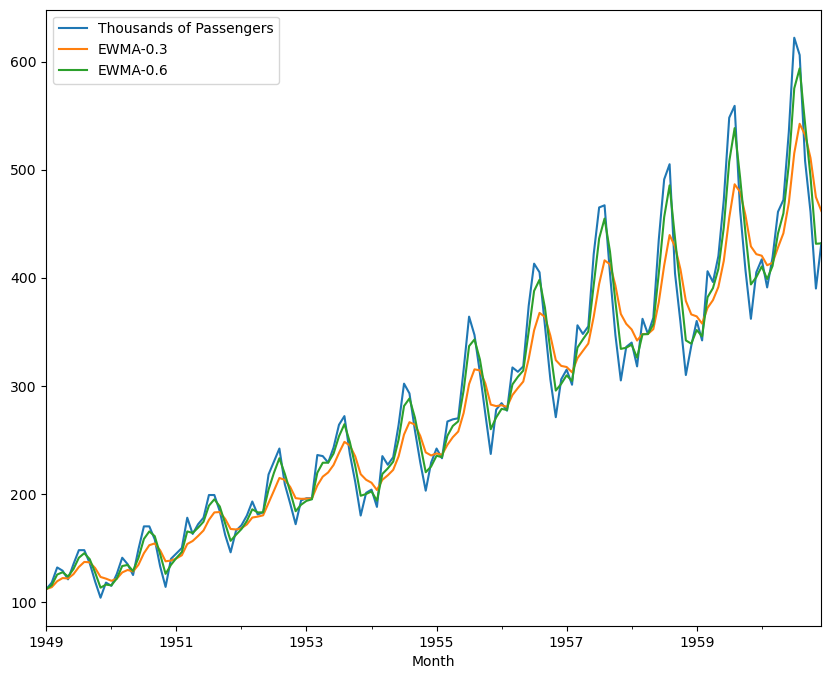

In [37]:
df[['Thousands of Passengers','EWMA-0.3','EWMA-0.6']].plot(figsize=(10,8))
plt.show()

## Decomposition

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1500x800 with 0 Axes>

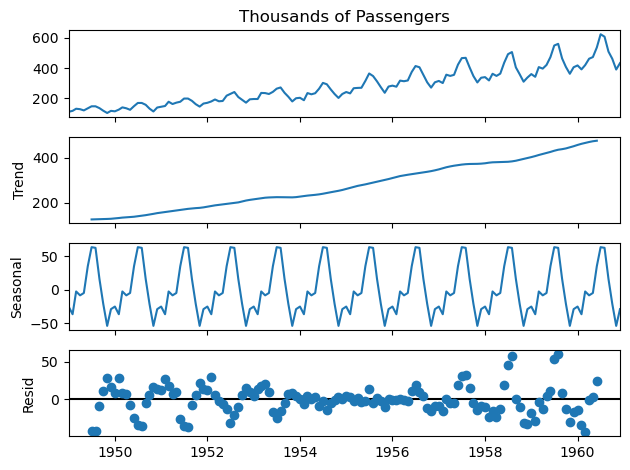

In [39]:
result = seasonal_decompose(df['Thousands of Passengers'], model='additive')
# result = seasonal_decompose(df['Thousands of Passengers'], model='multiplicative')
fig = plt.figure(figsize=(15,8))  
result.plot()
plt.show()

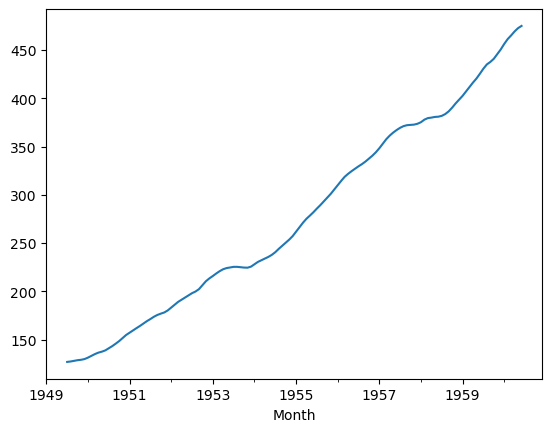

In [40]:
result.trend.plot()
plt.show()

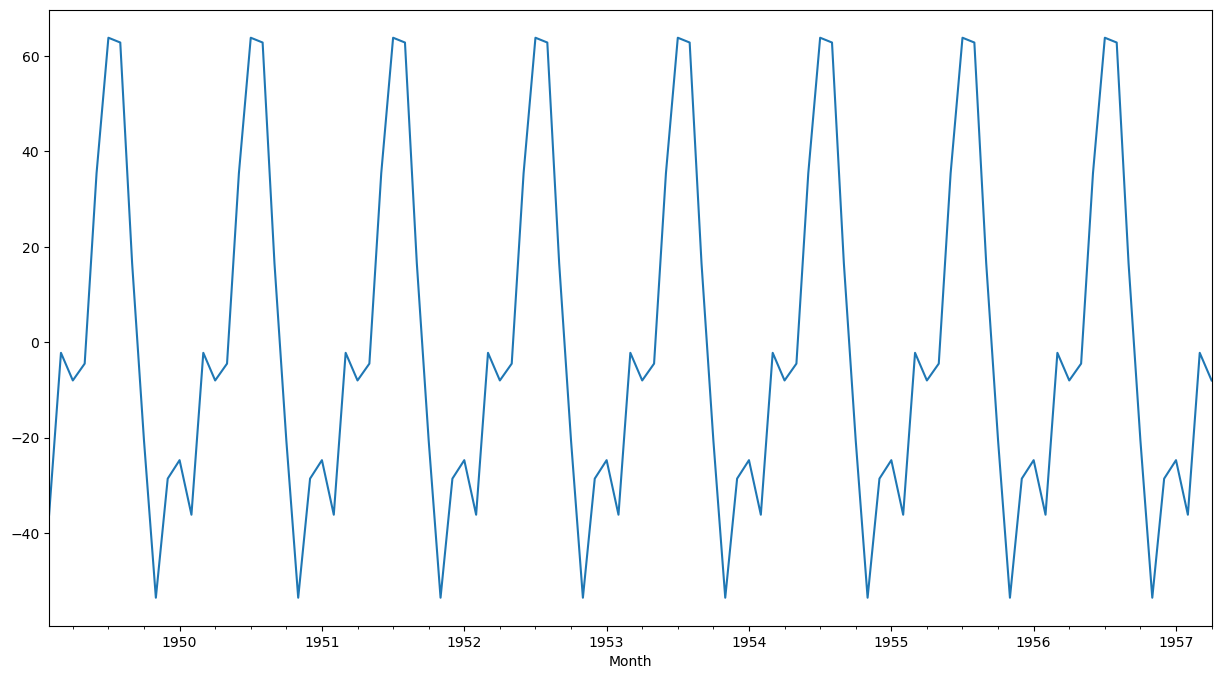

In [41]:
fig = plt.figure(figsize=(15,8))  
result.seasonal[1:100].plot()
plt.show()

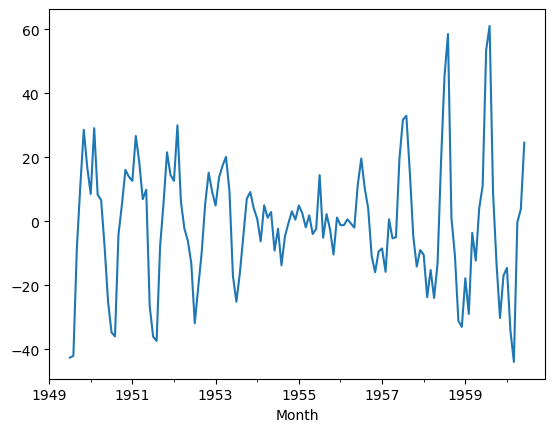

In [42]:
result.resid.plot()
plt.show()